# SALT3 Single Spectrum Fitting with Gaussian Process Residuals
This notebook implements a Gaussian Process (GP) to model the systematic template residuals (model mismatch) when fitting a single supernova spectrum with SALT3. We use the `george` GP package with a Matérn-3/2 kernel to model the correlated residuals, and bin the spectrum to 20 Å resolution to make the GP computation computationally efficient and numerically robust.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot
import george
from george import kernels

SPECTRA_DIR = '../data/all_spectra_dereddened'
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 300

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')


## 1. Helper Functions

In [2]:
def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

def bin_spectrum(wave, flux, err, bin_width=20.0):
    wmin, wmax = 3500.0, 8000.0
    bins = np.arange(wmin, wmax + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_flux = []
    bin_err = []
    for i in range(len(bins) - 1):
        mask = (wave >= bins[i]) & (wave < bins[i+1])
        if np.any(mask):
            w = 1.0 / err[mask]**2
            flux_mean = np.sum(flux[mask] * w) / np.sum(w)
            err_mean = 1.0 / np.sqrt(np.sum(w))
            bin_flux.append(flux_mean)
            bin_err.append(err_mean)
        else:
            bin_flux.append(0.0)
            bin_err.append(1e10)
    return bin_centers, np.array(bin_flux), np.array(bin_err)


In [3]:
def run_fit2(wavelength, flux, flux_err, mjd_obs, nlive, redshift=None, bin_width=20.0):
    # Bin the spectrum first to speed up GP operations (O(N^3))
    wave_b, flux_b, err_b = bin_spectrum(wavelength, flux, flux_err, bin_width=bin_width)

    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)

    # Parameters: physical + GP hyperparameters (log amplitude and log correlation length scale)
    params = ['t0', 'x1', 'c', 'log_gp_amp', 'log_gp_len']
    
    median_flux = np.median(flux_b)
    priors = {
        't0': (-30, 30), 
        'x1': (-4, 4), 
        'c': (-1, 1),
        'log_gp_amp': (np.log(1e-4 * median_flux), np.log(10.0 * median_flux)),
        'log_gp_len': (np.log(20.0), np.log(1000.0))  # correlation length between 20 A and 1000 A
    }

    # Reference log-determinant constant of statistical errors to subtract 
    # to avoid giant offset constants and overflow in dynesty plots
    log_det_ref = -0.5 * np.sum(np.log(2.0 * np.pi * err_b**2))

    # Prior transform
    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    # Loglikelihood function
    def ll(t):
        p_dict = dict(zip(params, t))
        gp_amp = np.exp(p_dict.pop('log_gp_amp'))
        gp_len = np.exp(p_dict.pop('log_gp_len'))

        t0_offset = p_dict.pop('t0')
        t0_mjd = mjd_obs - (t0_offset * (1 + redshift))

        model.set(t0 = t0_mjd)
        model.set(**p_dict)
        model.set(x0=1.0)

        try:
            m_flux_unit = model.flux(mjd_obs, wave_b)
        except Exception:
            return -1e10

        # Construct Matern 3/2 GP kernel
        kernel = gp_amp**2 * kernels.Matern32Kernel(metric=gp_len**2)
        gp = george.GP(kernel)
        
        try:
            gp.compute(wave_b, err_b)
        except Exception:
            return -1e10

        # Optimal linear scaling factor (x0) under GP covariance
        try:
            K_inv_m = gp.solver.apply_inverse(m_flux_unit)
            num = np.sum(flux_b * K_inv_m)
            den = np.sum(m_flux_unit * K_inv_m)
        except Exception:
            return -1e10

        if den <= 0: return -1e10
        x0_best = num / den
        if x0_best <= 0: return -1e10

        residuals = flux_b - x0_best * m_flux_unit
        
        try:
            val = gp.log_likelihood(residuals) - log_det_ref
        except Exception:
            return -1e10
            
        return val if not np.isnan(val) else -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rwalk')
    sampler.run_nested()
    return sampler.results, params


## 2. Load Data
Select a spectrum from the `data/all_spectra_dereddened` directory.

Found metadata for sn2000B-20000128.13-fast.flm: z=0.0191, mjd_max=51571.13
True Phase: 8.57 d
SNID Phase: 7.35 d
Subtype: nan


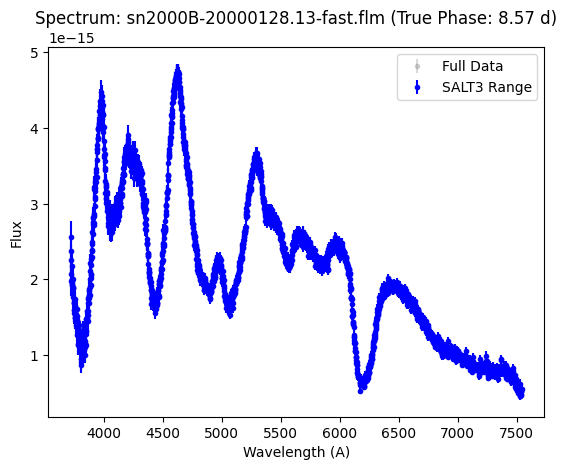

0.0191


In [4]:
# Example file
FILENAME = 'sn2000B-20000128.13-fast.flm'

# Get params from SNID results
true_phase = None
snid_phase = None
mjd_max = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]
        mjd_max = row['MJD'].values[0]
        z = row['redshift'].values[0]


if mjd_max is not None:
    print(f"Found metadata for {FILENAME}: z={z}, mjd_max={mjd_max}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

print(z)

## 3. Run Nested Sampling

In [5]:
results, params_names = run_fit2(wave_f, flux_f, err_f, mjd_max, NLIVE, redshift=z)
print("Fit complete.")

iter: 1 | bound: 0 | nc: 1 | ncall: 301 | eff(%):  0.332 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.341 | dlogz:    inf >  0.309                                                      

iter: 2 | bound: 0 | nc: 1 | ncall: 302 | eff(%):  0.662 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

iter: 3 | bound: 0 | nc: 1 | ncall: 303 | eff(%):  0.990 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.495 | dlogz:    inf >  0.309                                                      

iter: 4 | bound: 0 | nc: 2 | ncall: 305 | eff(%):  1.311 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

iter: 5 | bound: 0 | nc: 2 | ncall: 307 | eff(%):  1.629 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

...

iter: 52 | +297 | bound: 0 | nc: 1 | ncall: 664 | eff(%): 95.095 | loglstar:   -inf < -4764.095 <    inf | logz: -4764.300 +/-    nan | dlogz:  0.013 >  0.309                                        

iter: 52 | +298 | bound: 0 | nc: 1 | ncall: 665 | eff(%): 95.368 | loglstar:   -inf < -4764.095 <    inf | logz: -4764.296 +/-    nan | dlogz:  0.010 >  0.309                                        

iter: 52 | +299 | bound: 0 | nc: 1 | ncall: 666 | eff(%): 95.640 | loglstar:   -inf < -4764.095 <    inf | logz: -4764.293 +/-    nan | dlogz:  0.007 >  0.309                                        

iter: 52 | +300 | bound: 0 | nc: 1 | ncall: 667 | eff(%): 95.913 | loglstar:   -inf < -4764.095 <    inf | logz: -4764.289 +/-    nan | dlogz:  0.003 >  0.309                                        

Fit complete.


## 4. Convergence Plots
Check if the evidence has converged and look at the parameter traces.

/Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


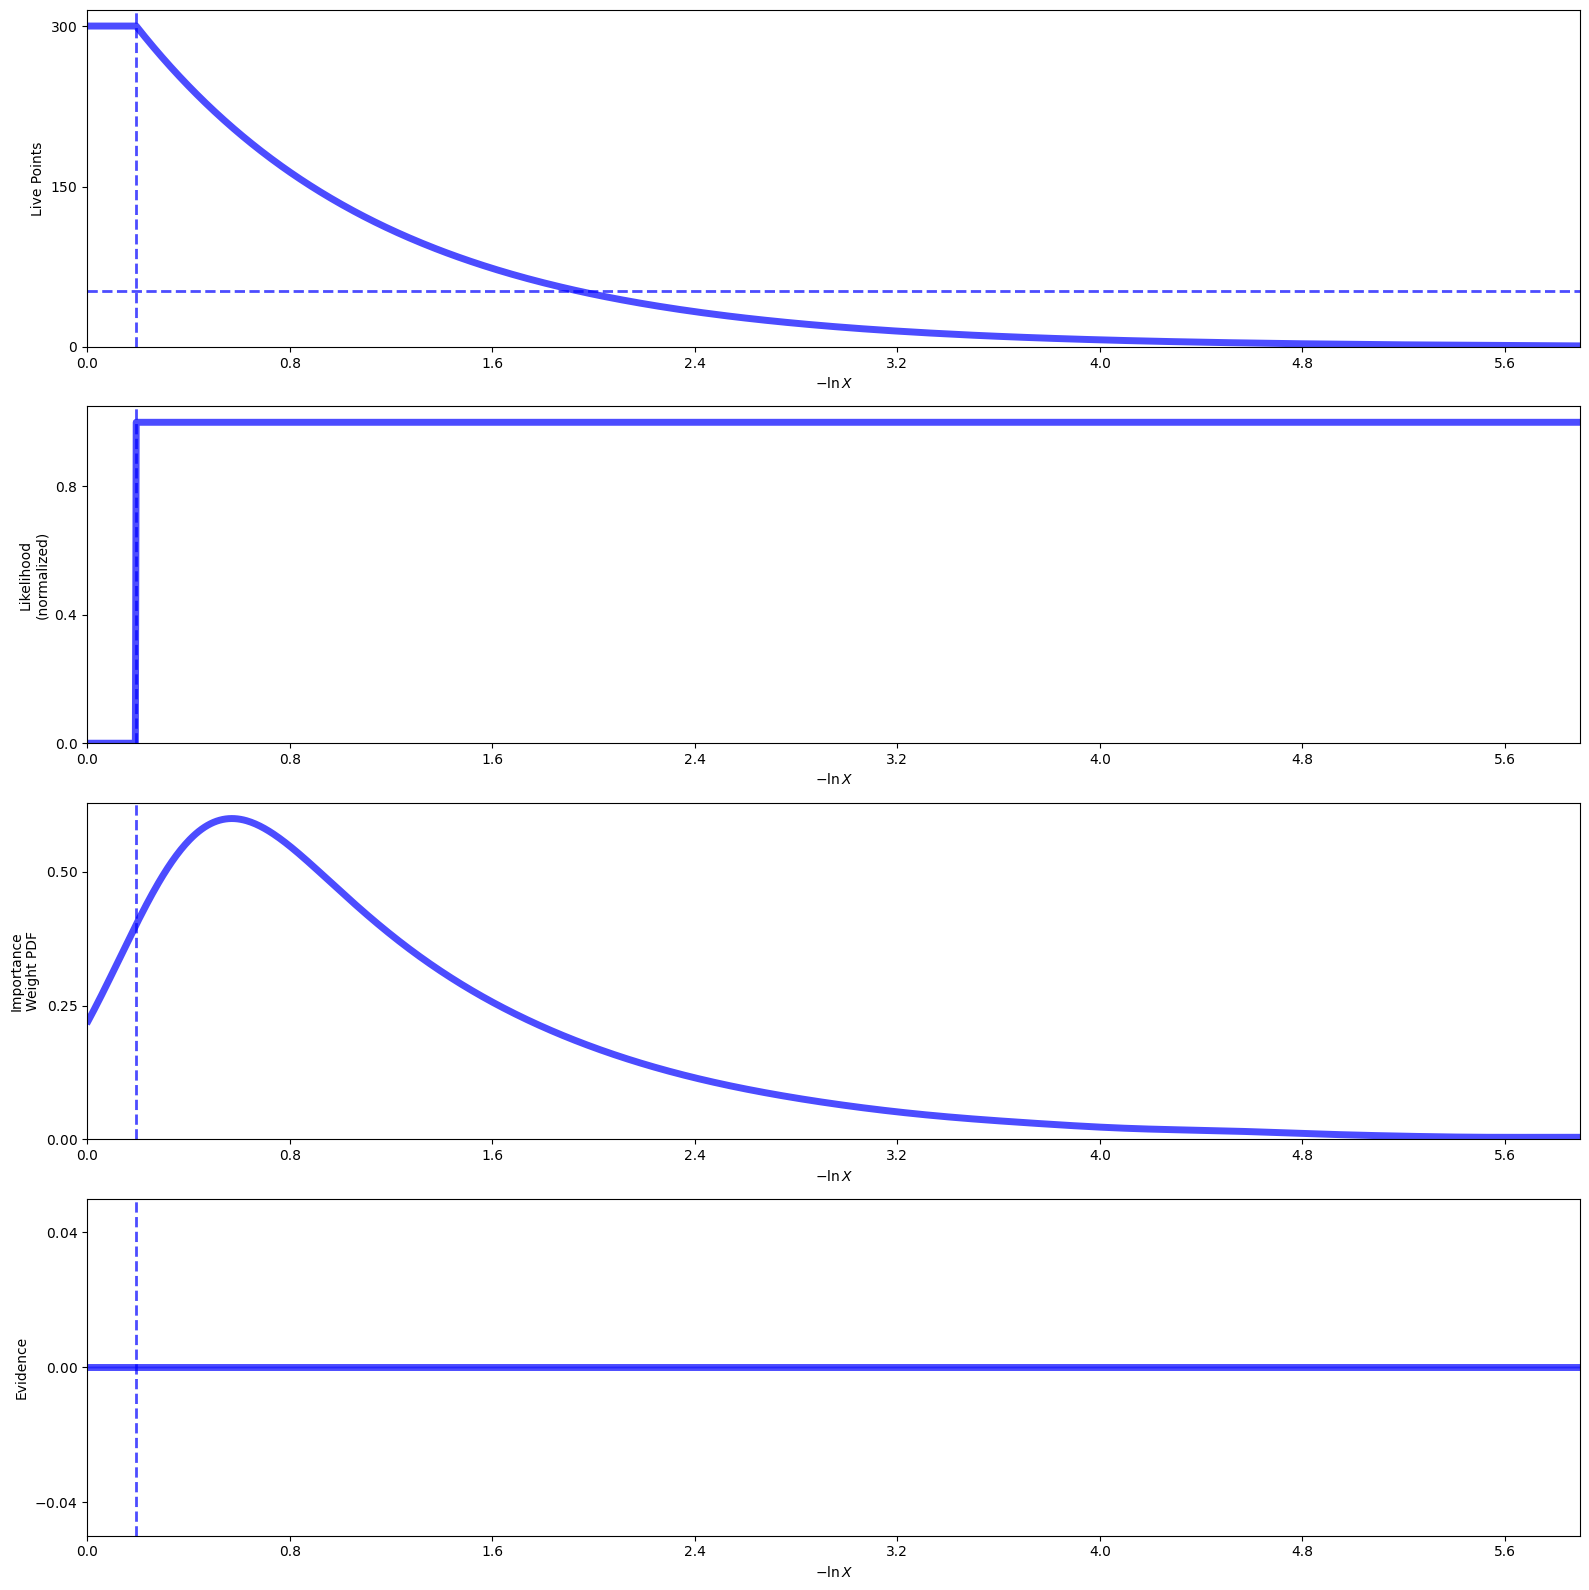

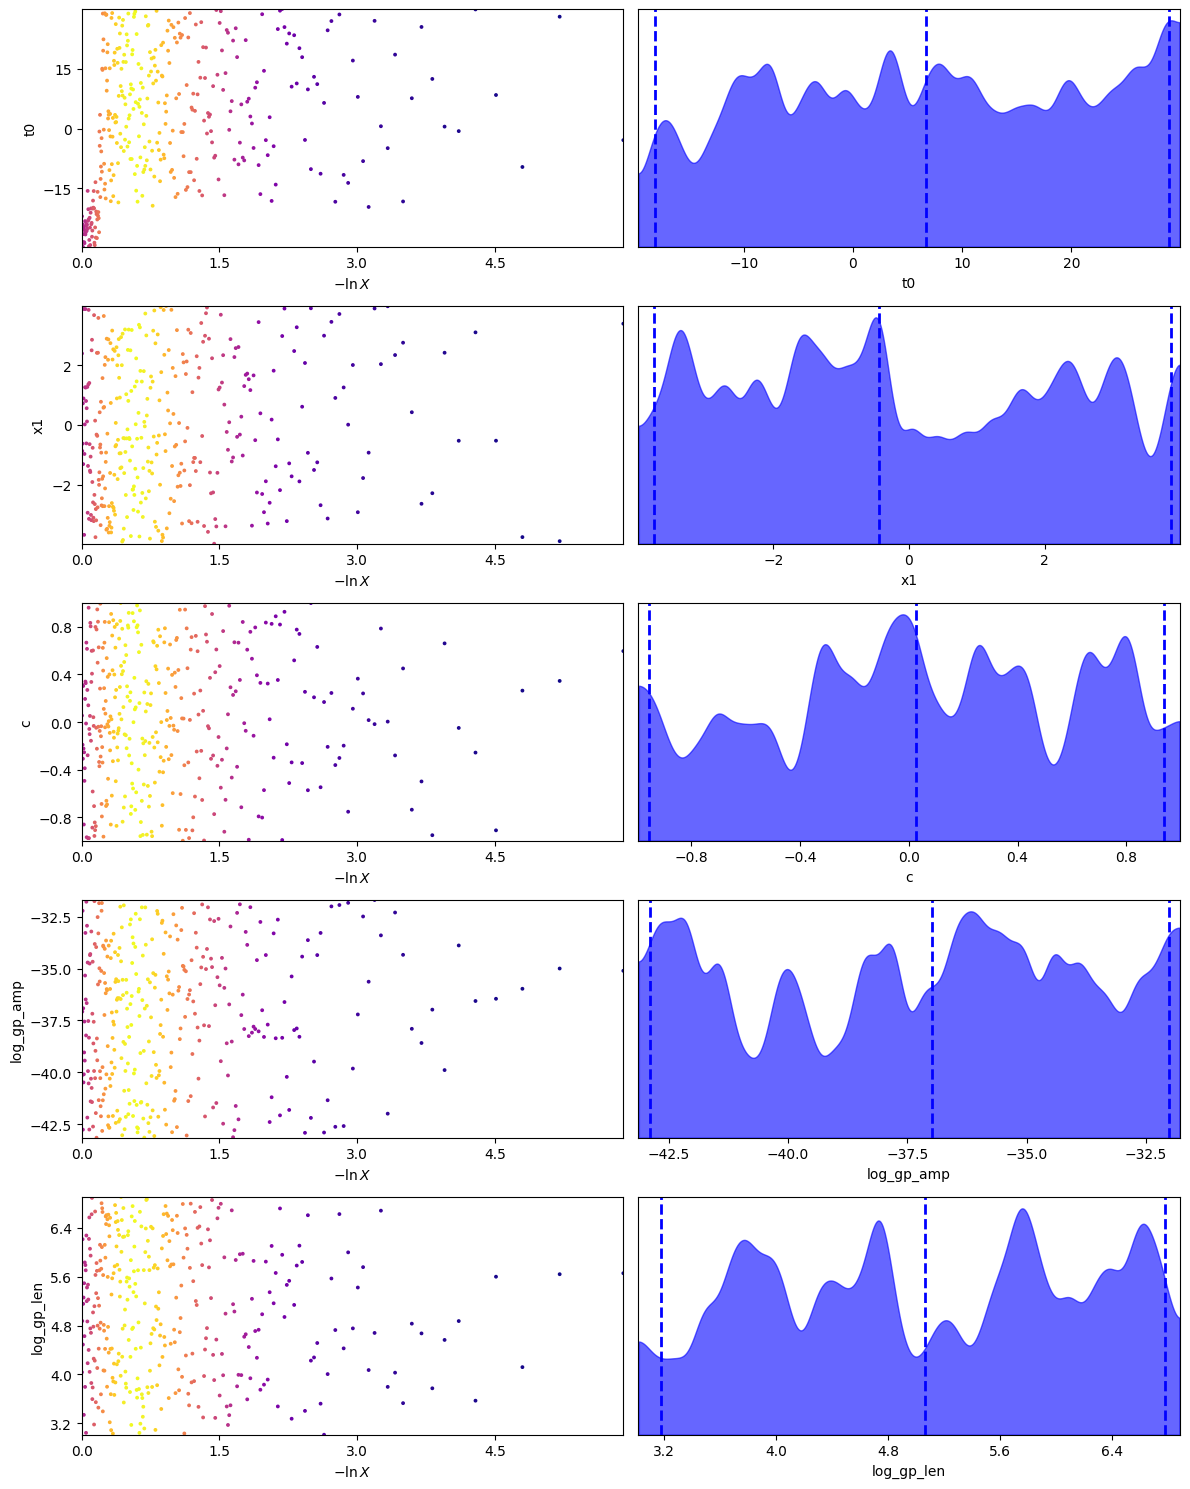

In [6]:
fig, axes = dyplot.runplot(results)
plt.tight_layout()
plt.show()

fig, axes = dyplot.traceplot(results, labels=params_names)
plt.tight_layout()
plt.show()

## 5. Corner Plot
Visualize parameter correlations and marginalized distributions.

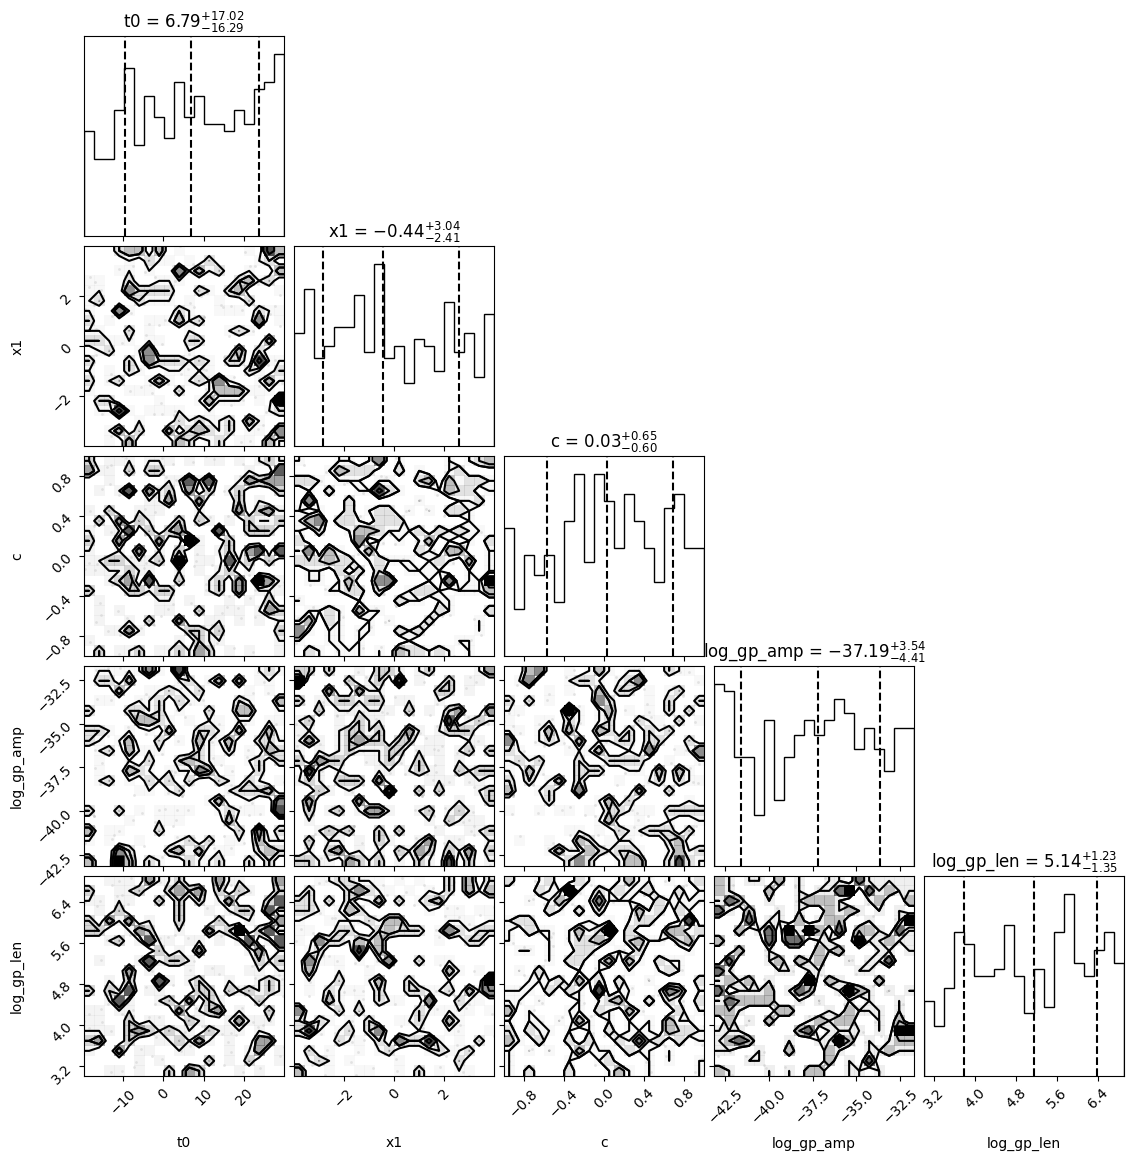

In [7]:
# Resample for equal weights
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

fig = corner.corner(samples, labels=params_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

## 6. Model vs Data
Overlay the best-fit model on the observed spectrum.

Median GP Amplitude: 7.044e-17
Median GP Correlation Length: 171.4 A


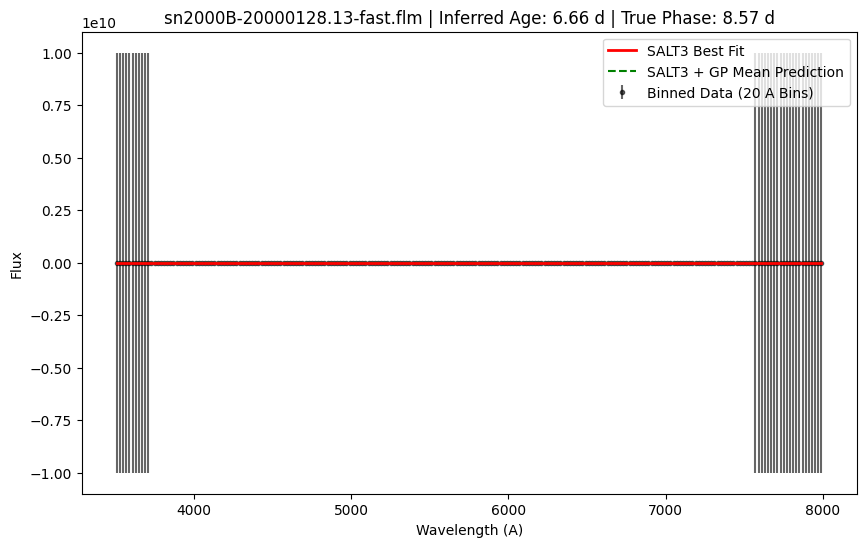

In [8]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

# Extract GP parameters
gp_amp = np.exp(p_dict.pop('log_gp_amp'))
gp_len = np.exp(p_dict.pop('log_gp_len'))
print(f"Median GP Amplitude: {gp_amp:.3e}")
print(f"Median GP Correlation Length: {gp_len:.1f} A")

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=z)
model.set(**p_dict)

t0_offset = p_dict['t0']
t0_mjd = mjd_max - t0_offset * (1 + z)   # undo the transform from run_fit2

model.set(t0=t0_mjd)
model.set(x1=p_dict['x1'], c=p_dict['c'])
model.set(x0=1.0)

# Evaluate binned model
wave_b, flux_b, err_b = bin_spectrum(wave_f, flux_f, err_f, bin_width=20.0)
m_flux_unit_b = model.flux(mjd_max, wave_b)

# Compute best x0 under GP covariance
kernel = gp_amp**2 * kernels.Matern32Kernel(metric=gp_len**2)
gp = george.GP(kernel)
gp.compute(wave_b, err_b)
K_inv_m = gp.solver.apply_inverse(m_flux_unit_b)
x0_best = np.sum(flux_b * K_inv_m) / np.sum(m_flux_unit_b * K_inv_m)
model.set(x0=x0_best)

# Evaluate best fit model on the original grid and the binned grid
model_flux = model.flux(mjd_max, wave_f)
model_flux_b = m_flux_unit_b * x0_best
residuals_b = flux_b - model_flux_b

# Compute GP mean prediction
gp_mean_b = gp.predict(residuals_b, wave_b, return_cov=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(wave_b, flux_b, yerr=err_b, fmt='.', color='black', alpha=0.6, label='Binned Data (20 A Bins)')
plt.plot(wave_b, model_flux_b, color='red', lw=2, label='SALT3 Best Fit', zorder=10)
plt.plot(wave_b, model_flux_b + gp_mean_b, color='green', lw=1.5, linestyle='--', label='SALT3 + GP Mean Prediction', zorder=5)

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()


In [9]:
SNID_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfa_pipeline/all_spectra_dereddened_snidded_supersnid'

# The number of the comp file we want to pick
no = '01'

base_filename = FILENAME.rsplit('.', 1)[0]

snid_output_name = f"{base_filename}_comp00{no}_snidflux.dat"

compfile = os.path.join(SNID_DIR, snid_output_name)


compwave, compflux, comperr = load_flm_spectrum(compfile)
mask = (compwave > 3500) & (compwave < 8000)
compwave_f, compflux_f, comperr_f = compwave[mask], compflux[mask], comperr[mask]


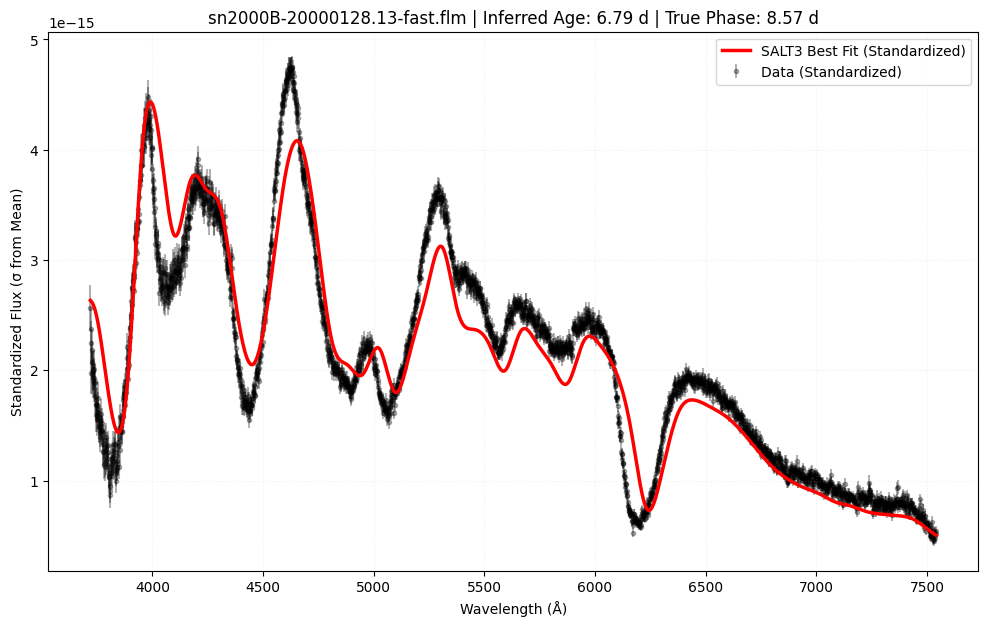

In [10]:
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# # 3. SNID Fit (Blue dots/line)
# plt.errorbar(compwave_f, compflux_f, yerr=comperr_f, fmt='.', color='blue',
#              alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
# plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0'])
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

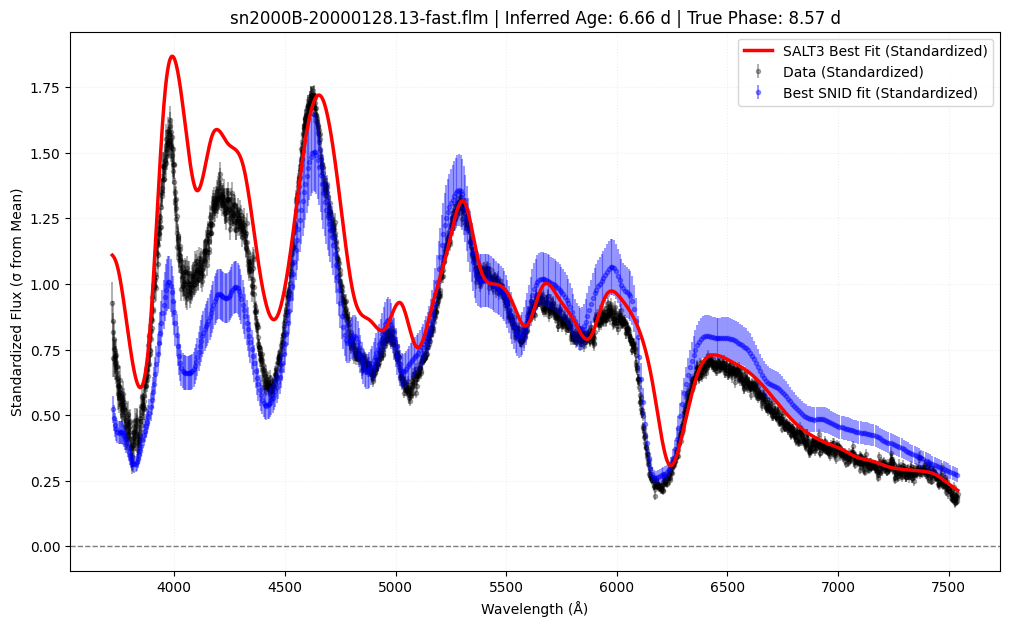

In [11]:
# --- Scalar Normalization (Preserves Continuum & Feature Depth) ---
def normalize_flux(wave, flux, error=None, wmin=5000, wmax=5500):
    """
    Scales the spectrum so the median flux in the chosen wavelength 
    window (wmin to wmax) is exactly 1.0.
    """
    # 1. Create a mask for the anchor window
    mask = (wave >= wmin) & (wave <= wmax)
    
    # Fallback: if the spectrum doesn't cover the window, use the whole array
    if not np.any(mask):
        mask = np.ones(len(wave), dtype=bool)

    # 2. Find the median flux in that window (median ignores noise spikes)
    scale_factor = np.median(flux[mask])

    # 3. Scale the flux
    norm_flux = flux / scale_factor

    if error is not None:
        # Errors must be scaled by the same factor
        norm_error = error / scale_factor
        return norm_flux, norm_error
    
    return norm_flux

# Process all three datasets using the new function
flux_f_norm, err_f_norm = normalize_flux(wave_f, flux_f, err_f)
model_flux_norm = normalize_flux(wave_f, model_flux) # Assuming model uses same wave grid
compflux_f_norm, comperr_f_norm = normalize_flux(compwave_f, compflux_f, comperr_f)
# -----------------------------------------------------------
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f_norm, yerr=err_f_norm, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux_norm, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# 3. SNID Fit (Blue dots/line)
plt.errorbar(compwave_f, compflux_f_norm, yerr=comperr_f_norm, fmt='.', color='blue',
             alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0']) / (1 + z)
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

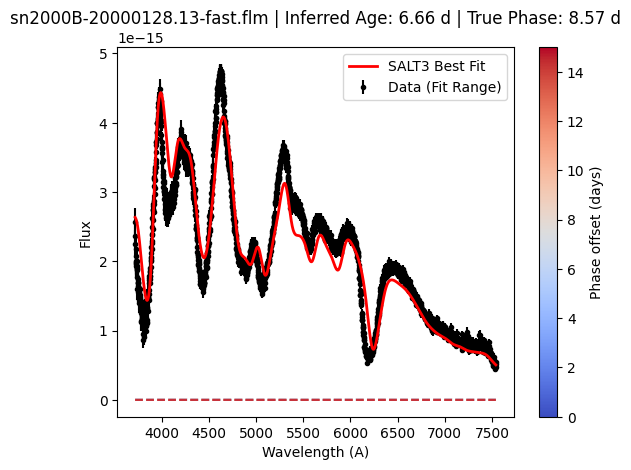

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_values = np.arange(0, 16, 1)
norm = Normalize(vmin=t_values.min(), vmax=t_values.max())
cmap = plt.cm.coolwarm

for t in t_values:
    color = cmap(norm(t))
    plt.plot(wave_f, model.flux(t, wave_f),
             color=color, linestyle='--', alpha=0.5)

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit', zorder=10)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Phase offset (days)', ax=plt.gca())

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()